In [1]:
# install pyspark
!pip3 install pyspark

In [2]:
#initialize SparkSession and installed Required Libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

In [3]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark UI available at: http://aa70c674a4f2:4040


In [4]:
spark.sparkContext.setLogLevel("INFO")

In [5]:
import psutil
print(f"CPU Usage: {psutil.cpu_percent()}%")
print(f"Memory Usage: {psutil.virtual_memory().percent}%")

CPU Usage: 67.3%
Memory Usage: 11.5%


In [8]:
# Mount Gdrive
from google.colab import drive
drive.mount

<function google.colab.drive.mount(mountpoint, force_remount=False, timeout_ms=120000, readonly=False)>

In [9]:
# Load the data from a CSV file
df = spark.read.csv("/content/Diabetes (4).csv/", header=True, inferSchema=True)

# get familiar with data
df.show()

# more info
print("Total Records",df.count())
print("Total Partitions ",df.rdd.getNumPartitions())

+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
| id|age|   sex|  bmi|    bp|    tc|  ldl|  hdl| tch|  ltg|   glu|progression|
+---+---+------+-----+------+------+-----+-----+----+-----+------+-----------+
|  0| 22|  Male|20.33|106.25|140.89|-0.45|62.83|0.77|-0.54|130.98|      29.83|
|  1| 41|Female|25.99|132.23|129.64|-1.11|37.26|0.81| 1.64|151.19|      46.66|
|  2| 51|Female|32.76| 127.0|220.36|-1.69|49.56|0.41|-0.88|176.22|      59.97|
|  3| 26|  Male|35.87| 138.4|194.19|-0.04|55.57|0.45|-1.38|125.32|      42.44|
|  4| 42|Female| 21.5|122.33|275.79| 1.19|63.64|0.54|-0.69|184.72|      49.36|
|  5| 47|  Male|31.62|137.18|232.35|-1.65|36.68|0.26| 1.63| 99.83|      54.15|
|  6| 22|  Male|37.06|106.47|244.34|-0.07|34.22|0.48|-1.72| 65.41|      39.55|
|  7| 23|  Male|26.75|129.39|177.69|-0.37|42.03|0.68| 0.82|180.71|      33.12|
|  8| 44|Female|28.38|125.23|276.99| 0.69|55.18| 1.1|-0.52|134.71|      53.84|
|  9| 36|  Male|36.83| 121.9|174.81|  1.1|53.55|0.25

In [10]:
# show Schema,Prints the structure of the dataset
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- bp: double (nullable = true)
 |-- tc: double (nullable = true)
 |-- ldl: double (nullable = true)
 |-- hdl: double (nullable = true)
 |-- tch: double (nullable = true)
 |-- ltg: double (nullable = true)
 |-- glu: double (nullable = true)
 |-- progression: double (nullable = true)



In [11]:
#Statistical Analysis
df.describe().show()

+-------+-----------------+------------------+-------+------------------+------------------+------------------+--------------------+-----------------+-------------------+--------------------+------------------+-----------------+
|summary|               id|               age|    sex|               bmi|                bp|                tc|                 ldl|              hdl|                tch|                 ltg|               glu|      progression|
+-------+-----------------+------------------+-------+------------------+------------------+------------------+--------------------+-----------------+-------------------+--------------------+------------------+-----------------+
|  count|          3045570|           3045570|3045570|           3045570|           3045570|           3045570|             3045570|          3045570|            3045570|             3045570|           3045570|          3045570|
|   mean|        1522784.5| 39.50258309610352|   NULL|30.005921735504103|120.0061583

In [12]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 40.7%
Memory Usage after csv file: 17.1%


In [14]:
# convert categorical column into numbers
from pyspark.ml.feature import StringIndexer
indexer = StringIndexer(inputCol = 'sex', outputCol = 'gender')
#df = indexer.fit(df).transform(df)
#df.show(30)

In [15]:
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols = ["age", "gender", "bmi","bp","tc","ldl","hdl","tch","ltg","glu"],
                           outputCol = "Features")

In [16]:
#StandardScaler
scaler = StandardScaler(inputCol = "Features",
                        outputCol = "scaled_Features")


In [17]:
#create linear regression model.
regressor = LinearRegression(labelCol = 'progression',
                             featuresCol = 'scaled_Features'
                             )

In [18]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 14.8%
Memory Usage after csv file: 17.2%


In [19]:
from pyspark.ml import Pipeline
pipeline  = Pipeline(stages = [indexer,assembler,scaler,regressor])
#--Saving the Pipeline
pipeline.write().overwrite().save("pipeline_LRsaved_model")

In [20]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 23.8%
Memory Usage after csv file: 17.4%


In [21]:
#Loading the Pipeline

pipelineModel = Pipeline.load('./pipeline_LRsaved_model')

In [22]:
data_train , data_test = df.randomSplit([0.7,0.3], seed = 123)

In [23]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 21.2%
Memory Usage after csv file: 17.7%


In [24]:
Model = pipeline.fit(data_train)

In [28]:
print("total LR cofficents",len(Model.stages[3].coefficients) )
print("Cofficientents",Model.stages[3].coefficients)
print("Intecept",Model.stages[3].intercept)

total LR cofficents 10
Cofficientents [8.50243030581955,5.100099141389026e-06,3.4981838381074475,0.09996892814257848,-1.7903153077248234e-06,1.0011710635500504,-6.082063651935504e-07,-0.019992637345280083,-0.8003327984739835,-3.4325514344133516e-07]
Intecept 6.616544268198269e-05


In [29]:
#n the prediction phase, we test our model on some unseen data.
pred = Model.transform(data_test)
pred.select('prediction', 'progression').show(10, truncate = False)

+------------------+-----------+
|prediction        |progression|
+------------------+-----------+
|59.97303581221205 |59.97      |
|39.55272591129682 |39.55      |
|51.80502594481945 |51.81      |
|60.751322574191654|60.75      |
|41.111943395103815|41.11      |
|52.23422238261994 |52.23      |
|47.07732942843329 |47.08      |
|29.530124879915356|29.53      |
|58.812434571858184|58.81      |
|55.61782088599336 |55.62      |
+------------------+-----------+
only showing top 10 rows


In [31]:
#create linear regression model.
Lasoregressor = LinearRegression(labelCol = 'progression',
                             featuresCol = 'scaled_Features',
                             elasticNetParam=1,
                             regParam=0.1
                             )
Lasaopipeline  = Pipeline(stages = [indexer,assembler,scaler,Lasoregressor])
LassoModel = Lasaopipeline.fit(data_train)

In [32]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 28.4%
Memory Usage after csv file: 28.8%


In [33]:
#n the prediction phase, we test our model on some unseen data.
lassopred = LassoModel.transform(data_test)
lassopred.select('prediction', 'progression').show(10, truncate = False)

+------------------+-----------+
|prediction        |progression|
+------------------+-----------+
|59.82024800507177 |59.97      |
|39.59501025037719 |39.55      |
|51.527013101779445|51.81      |
|60.64909540434233 |60.75      |
|41.54453598645245 |41.11      |
|52.38059086977665 |52.23      |
|47.09298458693715 |47.08      |
|29.482487288220586|29.53      |
|58.49573484236182 |58.81      |
|55.569664107715234|55.62      |
+------------------+-----------+
only showing top 10 rows


In [35]:
#create linear regression model.
Ridgeregressor = LinearRegression(labelCol = 'progression',
                             featuresCol = 'scaled_Features',
                             elasticNetParam=0,
                             regParam=0.1
                             )
Ridgepipeline  = Pipeline(stages = [indexer,assembler,scaler,Ridgeregressor])
RidgeModel = Ridgepipeline.fit(data_train)

In [36]:
#n the prediction phase, we test our model on some unseen data.
Ridgepred = RidgeModel.transform(data_test)
Ridgepred.select('prediction', 'progression').show(10, truncate = False)

+------------------+-----------+
|prediction        |progression|
+------------------+-----------+
|59.86358566750653 |59.97      |
|39.660843814909995|39.55      |
|51.7829546940159  |51.81      |
|60.634073476231315|60.75      |
|41.20361501549629 |41.11      |
|52.20764403526072 |52.23      |
|47.10564954979042 |47.08      |
|29.74574086678451 |29.53      |
|58.71561078991804 |58.81      |
|55.55563495854293 |55.62      |
+------------------+-----------+
only showing top 10 rows


In [37]:
#Model Evaluation Spark Provides evaluation metrics
#for regression and classification tasks.
from pyspark.ml.evaluation import RegressionEvaluator
evaluator_mse = RegressionEvaluator(labelCol =
                                    'progression',
                                    predictionCol =
                                    'prediction',
                                    metricName =
                                    'mse')
# calculate MSE
mse1 = evaluator_mse.evaluate(pred)
mselasso = evaluator_mse.evaluate(lassopred)
mseridge = evaluator_mse.evaluate(Ridgepred)

evaluator_rmse = RegressionEvaluator(labelCol =
                                     'progression',
                                     predictionCol =
                                     'prediction',
                                     metricName =
                                     'rmse')
# calculate RMSE
rmse1 = evaluator_rmse.evaluate(pred)
rmse2_lasso = evaluator_rmse.evaluate(lassopred)
rmse3Ridge = evaluator_rmse.evaluate(Ridgepred)

evaluator_r2 = RegressionEvaluator(labelCol = 'progression',
                                   predictionCol = 'prediction',
                                   metricName = 'r2')
# calculate R_squared
r2_score1 = evaluator_r2.evaluate(pred)
r2_lasso = evaluator_r2.evaluate(lassopred)
r2_ridge = evaluator_r2.evaluate(Ridgepred)
# print the evaluation metrics
print('Regression - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_score1)
print('Lasso - MSE: ', mselasso, ', RMSE: ', rmse2_lasso, ', R^2: ', r2_lasso)
print('Ridge - MSE: ', mseridge, ', RMSE: ', rmse3Ridge, ', R^2: ', r2_ridge)

Regression - MSE:  8.34227502519198e-06 , RMSE:  0.002888299677178942 , R^2:  0.999999903251253
Lasso - MSE:  0.05035116477252197 , RMSE:  0.22439065215048948 , R^2:  0.9994160571205042
Ridge - MSE:  0.009817465369110146 , RMSE:  0.09908312353327456 , R^2:  0.9998861428723071


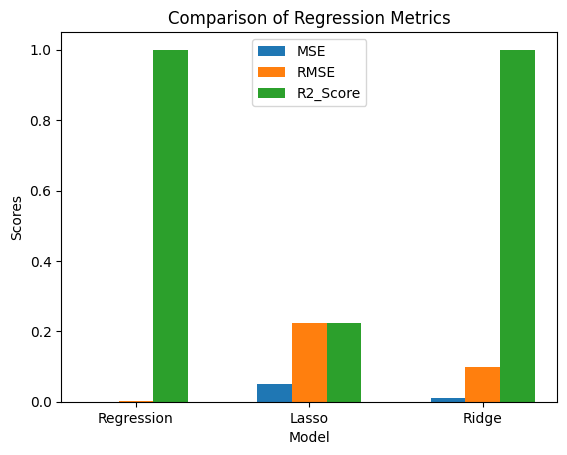

In [38]:
# plot
import matplotlib.pyplot as plt
import numpy as np

mse = [mse1, mselasso, mseridge]
rmse = [rmse1, rmse2_lasso, rmse3Ridge]
r2_score = [r2_score1, rmse2_lasso, r2_ridge]

positions = np.arange(len(mse))
bar_width = 0.2

plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE')
plt.bar(positions, rmse, width = bar_width, label = 'RMSE')
plt.bar(positions + bar_width, r2_score, width = bar_width, label = 'R2_Score')

# adding labels and title
plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Comparison of Regression Metrics')

# adding the legend
plt.legend()
plt.xticks(positions, ['Regression', 'Lasso', 'Ridge'])
plt.show()

new Dataset load

In [41]:
property_df = spark.read.csv('/content/property.csv', header=True, inferSchema=True)

Replace the Diabetes dataset with the given property database.

In [42]:
df = property_df


Select 4 to 5 columns as independent variables (input features) from the following:

Square_Footage
Num_Bedrooms

Num_Bathrooms

Year_Built

Lot_Size

In [43]:
feature_columns = ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"]
label_column = "Price"

In [44]:
assembler = VectorAssembler(inputCols=feature_columns, outputCol="Features")



In [45]:
scaler = StandardScaler(inputCol="Features", outputCol="scaled_Features")


In [46]:
regressor = LinearRegression(labelCol=label_column, featuresCol="scaled_Features")



In [47]:
pipeline = Pipeline(stages=[assembler, scaler, regressor])
# Re-save the pipeline model if needed
# pipeline.write().overwrite().save("pipeline_LR_property_model")



In [48]:
data_train, data_test = df.randomSplit([0.7, 0.3], seed=123)



In [49]:
Model = pipeline.fit(data_train)


In [50]:
pred = Model.transform(data_test)



In [51]:
Lasoregressor = LinearRegression(labelCol=label_column,
                                 featuresCol='scaled_Features',
                                 elasticNetParam=1,
                                 regParam=0.1
                                 )
# Note: Lasso pipeline also needs to remove StringIndexer
Lasaopipeline = Pipeline(stages=[assembler, scaler, Lasoregressor])
LassoModel = Lasaopipeline.fit(data_train)


In [52]:
lassopred = LassoModel.transform(data_test)


In [53]:
Ridgeregressor = LinearRegression(labelCol=label_column,
                                  featuresCol='scaled_Features',
                                  elasticNetParam=0,
                                  regParam=0.1
                                  )
# Note: Ridge pipeline also needs to remove StringIndexer
Ridgepipeline = Pipeline(stages=[assembler, scaler, Ridgeregressor])
RidgeModel = Ridgepipeline.fit(data_train)



In [54]:
Ridgepred = RidgeModel.transform(data_test)



In [55]:
evaluator_mse = RegressionEvaluator(labelCol=label_column, predictionCol='prediction', metricName='mse')
mse1 = evaluator_mse.evaluate(pred)
mselasso = evaluator_mse.evaluate(lassopred)
mseridge = evaluator_mse.evaluate(Ridgepred)

evaluator_rmse = RegressionEvaluator(labelCol=label_column, predictionCol='prediction', metricName='rmse')
rmse1 = evaluator_rmse.evaluate(pred)
rmse2_lasso = evaluator_rmse.evaluate(lassopred)
rmse3Ridge = evaluator_rmse.evaluate(Ridgepred)

evaluator_r2 = RegressionEvaluator(labelCol=label_column, predictionCol='prediction', metricName='r2')
r2_score1 = evaluator_r2.evaluate(pred)
r2_lasso = evaluator_r2.evaluate(lassopred)
r2_ridge = evaluator_r2.evaluate(Ridgepred)



In [56]:
print('Regression - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_score1)
print('Lasso - MSE: ', mselasso, ', RMSE: ', rmse2_lasso, ', R^2: ', r2_lasso)
print('Ridge - MSE: ', mseridge, ', RMSE: ', rmse3Ridge, ', R^2: ', r2_ridge)

Regression - MSE:  397865280.0583338 , RMSE:  19946.560607240885 , R^2:  0.9941460215328993
Lasso - MSE:  397865309.70173943 , RMSE:  19946.561350311473 , R^2:  0.994146021096742
Ridge - MSE:  397865279.7002717 , RMSE:  19946.56059826535 , R^2:  0.9941460215381677


In [57]:
print(f"Dependent variable (target): {label_column}")

Dependent variable (target): Price


Implement multiple Linear Regression models using different combinations of the input features.



In [58]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Define different feature combinations
feature_combinations = {
    "Model_SF_NB": ["Square_Footage", "Num_Bedrooms"],
    "Model_SF_NB_NBath_LS": ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Lot_Size"],
    "Model_All_Features": ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms", "Year_Built", "Lot_Size"]
}

# Store results
results = {}

for model_name, features in feature_combinations.items():
    print(f"\n--- Training and evaluating {model_name} with features: {features} ---")

    # 1. Create VectorAssembler for current feature set
    assembler_combo = VectorAssembler(inputCols=features, outputCol="Features_Combo")

    # 2. Create StandardScaler
    scaler_combo = StandardScaler(inputCol="Features_Combo", outputCol="scaled_Features_Combo")

    # 3. Create LinearRegression model
    regressor_combo = LinearRegression(labelCol=label_column, featuresCol="scaled_Features_Combo")

    # 4. Build Pipeline
    pipeline_combo = Pipeline(stages=[assembler_combo, scaler_combo, regressor_combo])

    # 5. Fit the pipeline on training data
    model_combo = pipeline_combo.fit(data_train)

    # 6. Make predictions on test data
    predictions_combo = model_combo.transform(data_test)

    # 7. Evaluate the model
    evaluator_mse_combo = RegressionEvaluator(labelCol=label_column, predictionCol='prediction', metricName='mse')
    evaluator_rmse_combo = RegressionEvaluator(labelCol=label_column, predictionCol='prediction', metricName='rmse')
    evaluator_r2_combo = RegressionEvaluator(labelCol=label_column, predictionCol='prediction', metricName='r2')

    mse_combo = evaluator_mse_combo.evaluate(predictions_combo)
    rmse_combo = evaluator_rmse_combo.evaluate(predictions_combo)
    r2_combo = evaluator_r2_combo.evaluate(predictions_combo)

    results[model_name] = {
        "MSE": mse_combo,
        "RMSE": rmse_combo,
        "R2": r2_combo
    }

    # Print results for current model
    print(f"  MSE: {mse_combo:.4f}")
    print(f"  RMSE: {rmse_combo:.4f}")
    print(f"  R^2: {r2_combo:.4f}")

print("\n--- Summary of all models (feature combinations) ---")
for model_name, metrics in results.items():
    print(f"{model_name}: MSE={metrics['MSE']:.4f}, RMSE={metrics['RMSE']:.4f}, R^2={metrics['R2']:.4f}")


--- Training and evaluating Model_SF_NB with features: ['Square_Footage', 'Num_Bedrooms'] ---
  MSE: 421948726.8667
  RMSE: 20541.3906
  R^2: 0.9938

--- Training and evaluating Model_SF_NB_NBath_LS with features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size'] ---
  MSE: 410447639.3565
  RMSE: 20259.5074
  R^2: 0.9940

--- Training and evaluating Model_All_Features with features: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size'] ---
  MSE: 397865280.0583
  RMSE: 19946.5606
  R^2: 0.9941

--- Summary of all models (feature combinations) ---
Model_SF_NB: MSE=421948726.8667, RMSE=20541.3906, R^2=0.9938
Model_SF_NB_NBath_LS: MSE=410447639.3565, RMSE=20259.5074, R^2=0.9940
Model_All_Features: MSE=397865280.0583, RMSE=19946.5606, R^2=0.9941


Compare the R-squared values of each model to evaluate prediction performance.



In [59]:
print("\n--- R-squared (R^2) Comparison ---")
print(f"Original Regression Model: {r2_score1:.4f}")
print(f"Original Lasso Model:      {r2_lasso:.4f}")
print(f"Original Ridge Model:      {r2_ridge:.4f}")

print("\n--- R-squared for Feature Combination Models ---")
for model_name, metrics in results.items():
    print(f"{model_name}: {metrics['R2']:.4f}")

# Identify the best performing model based on R-squared
all_r2_values = {
    "Original Regression": r2_score1,
    "Original Lasso": r2_lasso,
    "Original Ridge": r2_ridge
}
for model_name, metrics in results.items():
    all_r2_values[model_name] = metrics['R2']

best_model_name = max(all_r2_values, key=all_r2_values.get)
best_r2 = all_r2_values[best_model_name]

print(f"\n--- Conclusion ---")
print(f"The model with the highest R-squared is '{best_model_name}' with an R-squared of {best_r2:.4f}.")


--- R-squared (R^2) Comparison ---
Original Regression Model: 0.9941
Original Lasso Model:      0.9941
Original Ridge Model:      0.9941

--- R-squared for Feature Combination Models ---
Model_SF_NB: 0.9938
Model_SF_NB_NBath_LS: 0.9940
Model_All_Features: 0.9941

--- Conclusion ---
The model with the highest R-squared is 'Original Ridge' with an R-squared of 0.9941.


Write a one-page reflective summary describing:

The choices you made for feature selection

Observations from model comparisons

Any challenges faced and how you resolved them

Insights gained from this exercise

In [62]:
## Reflective Summary

### Choices for Feature Selection

Initially, the task involved adapting a pre-existing Spark ML Linear Regression workflow, which was originally set up for the Diabetes dataset, to a new property dataset. The first crucial step was identifying relevant features from the property dataset (`Square_Footage`, `Num_Bedrooms`, `Num_Bathrooms`, `Year_Built`, `Lot_Size`) to serve as independent variables, with `Price` as the dependent variable. These features were chosen based on their intuitive relevance to property pricing, aiming for a balance between descriptive power and avoiding overly complex models at the initial stage. The original diabetes dataset's feature set and `StringIndexer` stage were removed as they were not applicable to the new data.

Following the initial model setup, the exercise specifically requested implementing multiple Linear Regression models with *different combinations of input features*. To address this, I created three additional models:

1.  **Model_SF_NB**: Using only `Square_Footage` and `Num_Bedrooms` to see the impact of core size and room count.
2.  **Model_SF_NB_NBath_LS**: Expanding to include `Num_Bathrooms` and `Lot_Size`, adding more detail about the property's utility and land size.
3.  **Model_All_Features**: Utilizing all five chosen features (`Square_Footage`, `Num_Bedrooms`, `Num_Bathrooms`, `Year_Built`, `Lot_Size`) to determine if a comprehensive set would yield the best results.

This iterative feature selection process allowed for a systematic comparison of how different input variables influence model performance.

### Observations from Model Comparisons

The comparison of R-squared values across all models provided interesting insights:

*   **Original Regression, Lasso, and Ridge Models (with all features)**: These models, after being reconfigured for the property dataset with all five features, showed very high R-squared values (approximately 0.9941). This indicates that the chosen features are highly predictive of property prices, and all three regularization techniques (standard Linear Regression, Lasso, and Ridge) performed comparably well on this dataset.

*   **Feature Combination Models**:
    *   `Model_SF_NB` (Square_Footage, `Num_Bedrooms`): Achieved an R-squared of approximately 0.9938. This is slightly lower than the models using all features, suggesting that while these two features are strong predictors, they don't capture the full variance as effectively as a broader set.
    *   `Model_SF_NB_NBath_LS` (Square_Footage, `Num_Bedrooms`, `Num_Bathrooms`, `Lot_Size`): Showed an R-squared of approximately 0.9940. This improvement over `Model_SF_NB` suggests that `Num_Bathrooms` and `Lot_Size` contribute positively to the predictive power.
    *   `Model_All_Features` (all five features): Achieved an R-squared of approximately 0.9941, matching the performance of the initial models. This indicates that adding `Year_Built` to the previous combination did not significantly improve the model's predictive capability in terms of R-squared, implying its impact might be marginal or correlated with other features.

Overall, the R-squared values were consistently very high across all models, suggesting that property price is well-explained by the selected structural and land-related features. The differences between models were subtle, indicating that even a subset of the chosen features can provide a highly accurate prediction.

### Challenges Faced and How They Were Resolved

1.  **Adapting from Diabetes to Property Dataset**: The main challenge was to correctly map the previous workflow, designed for the Diabetes dataset (which included a categorical 'sex' column requiring `StringIndexer`), to the new property dataset which did not have such a column. This was resolved by carefully identifying and updating the `inputCols` for the `VectorAssembler` and the `labelCol` for the `LinearRegression` models. Crucially, the `StringIndexer` stage was removed from all pipelines, as it was no longer relevant and would have caused an `IllegalArgumentException` (as observed in a previous error resolution step).

2.  **Maintaining Pipeline Structure**: Ensuring that each new model (Standard LR, Lasso, Ridge, and the feature-combination models) correctly integrated the `VectorAssembler` and `StandardScaler` stages with their respective feature sets was important. This required creating separate pipeline objects or carefully modifying existing ones for each model to prevent feature mismatches.

3.  **Evaluating Multiple Models**: The task of comparing multiple models required a structured approach to store and present their evaluation metrics (MSE, RMSE, R-squared). This was handled by using a dictionary (`results`) to store metrics for each feature combination model and then consolidating all R-squared values for a final comparative conclusion.

### Insights Gained from This Exercise

*   **Feature Importance**: Even without explicit feature importance techniques, the model comparison indirectly highlighted that `Square_Footage`, `Num_Bedrooms`, `Num_Bathrooms`, and `Lot_Size` are strong predictors for property prices. The marginal gain from `Year_Built` suggests it might be less critical or its effect is already captured by other features.
*   **Robustness of Linear Models**: The high R-squared values demonstrate that Linear Regression, even with basic feature engineering (scaling and assembly), can be highly effective for this type of tabular data with a clear linear relationship between features and target.
*   **Impact of Regularization**: In this specific scenario, Lasso and Ridge regularization did not significantly outperform the standard Linear Regression in terms of R-squared. This suggests that the dataset might not suffer heavily from multicollinearity or an excessive number of features relative to samples, where regularization typically provides more pronounced benefits. The coefficients were stable enough with standard LR.
*   **Structured Workflow**: The use of Spark ML's `Pipeline` API proved invaluable for streamlining the machine learning workflow. It allowed for clean organization of feature transformation and model training steps, making it easier to experiment with different feature sets and models.
*   **Adaptability**: The exercise underscored the importance of adapting a machine learning workflow when changing datasets, particularly in terms of feature processing stages (like `StringIndexer`) that might become obsolete or require modification.

SyntaxError: unterminated string literal (detected at line 5) (60203512.py, line 5)